# 4__MEMORISATION_ROBUSTNESS_CHECKS.ipynb

## Purpose
This notebook runs a comprehensive battery of memorisation falsification tests for the pluralistic ignorance / climate LLM paper. It addresses reviewer and co-author concerns that LLM performance in the main study might reflect retrieval from training data rather than structured inference.

## Four tests, in order

| Test | Cells | What it falsifies |
|------|-------|-------------------|
| **T1 — Direct recall probe** | 5–6 | Country-specific memorisation of GCCS values |
| **T2 — False global norm** | 7–9 | Global anchor (69%/43%) used as retrieval shortcut |
| **T3 — Training cutoff natural experiment** | 10–11 | Later cutoff → better recall → better performance |
| **T4 — Pre-publication Llama comparison** | 12–14 | Post-publication exposure driving Llama 4 performance |

*Proposed by Sandra Geiger (T2 and T4).*

## Dependencies
- `country_names.csv` — 125-country list (from Notebook 1)
- `data_final.csv` — country-level ground truth including `mean_other_willingness`
- `predictions_S8_country.csv` or `predictions_all_stages_long.csv` — Stage 8 predictions from Notebook 2
- `country_llm_prompts_outcome2_8stages.csv` — Stage 8 prompts from Notebook 1

---

In [5]:
import subprocess, sys
for pkg in ["openai", "anthropic", "together"]:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "--quiet"])
    print(f"✅ {pkg}")


[notice] A new release of pip is available: 23.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
✅ openai

[notice] A new release of pip is available: 23.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
✅ anthropic
✅ together

[notice] A new release of pip is available: 23.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [11]:
# ================================================================
# CELL 1: DO NOT RUN
# ================================================================
# The Deepnote environment already has all required packages from
# Notebook 2 (openai, anthropic, google-generativeai, together).
# Running pip install will break pydantic compatibility.
# Skip this cell entirely.
print("✓ Skipping — all packages already available from Notebook 2 environment")


✓ Skipping — all packages already available from Notebook 2 environment


In [6]:
# Source - https://stackoverflow.com/a/77868665
# Posted by Talha Tayyab
# Retrieved 2026-04-15, License - CC BY-SA 4.0

!pip install google-generativeai


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.1/155.1 kB 8.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.2/15.2 MB 55.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 49.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.1/91.1 kB 72.8 MB/s eta 0:00:00

[notice] A new release of pip is available: 23.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [7]:
# ================================================================
# CELL 2: Imports, config, keep-alive
# Uses same package versions as working Notebook 2 — do NOT install
# new packages as this breaks pydantic compatibility in Deepnote.
# ================================================================

import os, re, time, json, threading
import pandas as pd
import numpy as np
import matplotlib
matplotlib.rcParams.update({"font.family": "sans-serif", "font.size": 11})
import matplotlib.pyplot as plt

# These imports match Notebook 2 exactly — already installed in environment
from openai import OpenAI
import anthropic
import google.generativeai as genai   # deprecation warning is harmless — still works

# Keep-alive (prevents Deepnote timeout)
def keep_alive():
    while True:
        print(".", end="", flush=True)
        time.sleep(60)
threading.Thread(target=keep_alive, daemon=True).start()
print("✓ Keep-alive started\n")

# ----------------------------------------------------------------
# API keys
# ----------------------------------------------------------------
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
CLAUDE_API_KEY = os.getenv("CLAUDE_API_KEY")
GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")
LLAMA_API_KEY  = os.getenv("LLAMA_API_KEY")

# ----------------------------------------------------------------
# Model versions
# Note: claude-3-5-haiku-20241022 deprecated — using claude-haiku-4-5-20251001
# Claude Haiku 4.5 cutoff July 2025 (later than 3.5 Haiku July 2024)
# This strengthens T1: newer model had more post-publication exposure
# ----------------------------------------------------------------
MODELS = {
    "gpt"   : "gpt-4o-mini",
    "claude": "claude-haiku-4-5-20251001",
    "gemini": "gemini-2.5-flash",
    "llama" : "meta-llama/Llama-3.3-70B-Instruct-Turbo",  # Llama 3.3 70B Instruct Turbo — serverless on Together AI
    # Note: Llama 4 Maverick unavailable serverless; Llama API US-only.
    # Llama 3.3 70B cutoff Dec 2023 (pre-GCCS) — conservative for memorisation test.
}

# ----------------------------------------------------------------
# Training cutoff dates — used in T3
# ----------------------------------------------------------------
import datetime
REF_DATE = datetime.date(2023, 1, 1)
CUTOFF_DATES = {
    "gpt"   : datetime.date(2023, 10, 1),   # GPT-4o mini: October 2023
    "claude": datetime.date(2025, 7, 1),    # Claude Haiku 4.5: July 2025
    "llama" : datetime.date(2023, 12, 1),   # Llama-3.3-70B-Instruct-Turbo: December 2023 (pre-GCCS)
    # Footnote: Maverick (Aug 2024) was unavailable serverless; 3.3 70B is conservative — failure to recall is even less surprising for a pre-publication model.
    "gemini": datetime.date(2025, 1, 1),    # Gemini 2.5 Flash: January 2025
}
CUTOFF_DAYS = {k: (v - REF_DATE).days for k, v in CUTOFF_DATES.items()}

# GCCS publication dates
GCCS_PAPER_DATE   = datetime.date(2024, 2, 1)
GCCS_WEBSITE_DATE = datetime.date(2024, 4, 1)
GCCS_PAPER_DAYS   = (GCCS_PAPER_DATE  - REF_DATE).days
GCCS_WEBSITE_DAYS = (GCCS_WEBSITE_DATE - REF_DATE).days

print("✅ Configuration loaded")
print(f"   Models: {list(MODELS.keys())}")
for m, d in CUTOFF_DATES.items():
    pub = "PRE-pub" if d < GCCS_PAPER_DATE else "post-pub"
    print(f"   {m:8s} cutoff: {d}  ({pub})")


.✓ Keep-alive started

✅ Configuration loaded
   Models: ['gpt', 'claude', 'gemini', 'llama']
   gpt      cutoff: 2023-10-01  (PRE-pub)
   claude   cutoff: 2025-07-01  (post-pub)
   llama    cutoff: 2023-12-01  (PRE-pub)
   gemini   cutoff: 2025-01-01  (post-pub)
/root/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/tmp/ipykernel_99/1464527823.py:17: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai   # deprecation warning is harmless — still works


In [8]:
# ================================================================
# CELL 3: Shared helpers — API callers and extraction
# Caller functions match Notebook 2 exactly to ensure compatibility.
# ================================================================

def extract_number_0_100(text):
    """Extract a number 0-100 from JSON response or raw text."""
    if not isinstance(text, str):
        return None
    try:
        data = json.loads(text)
        if isinstance(data, dict):
            for key in ["prediction", "estimate", "value", "number", "percentage"]:
                if key in data:
                    return max(0.0, min(100.0, float(data[key])))
        elif isinstance(data, (int, float)):
            return max(0.0, min(100.0, float(data)))
    except:
        pass
    m = re.search(r"(\d+(?:\.\d+)?)", text)
    return max(0.0, min(100.0, float(m.group(1)))) if m else None


def call_model(model_name, prompt, system_prompt, max_retries=3):
    """Unified caller — routes to correct API. Matches Notebook 2 patterns exactly."""
    model_id = MODELS[model_name]

    for attempt in range(max_retries):
        try:
            if model_name == "gpt":
                client = OpenAI(api_key=OPENAI_API_KEY)
                resp = client.chat.completions.create(
                    model=model_id,
                    messages=[
                        {"role": "system", "content": system_prompt},
                        {"role": "user",   "content": prompt},
                    ],
                    temperature=0,
                    response_format={"type": "json_object"},
                )
                return extract_number_0_100(resp.choices[0].message.content)

            elif model_name == "claude":
                client = anthropic.Anthropic(api_key=CLAUDE_API_KEY)
                resp = client.messages.create(
                    model=model_id,
                    max_tokens=100,
                    temperature=0,
                    system=system_prompt,
                    messages=[{"role": "user", "content": prompt}],
                    tools=[],
                )
                return extract_number_0_100(resp.content[0].text)

            elif model_name == "gemini":
                # google.generativeai deprecation warning is harmless — still works
                genai.configure(api_key=GOOGLE_API_KEY)
                model_instance = genai.GenerativeModel(
                    model_name=model_id,
                    generation_config={"temperature": 0},
                )
                full_prompt = f"{system_prompt}\n\n{prompt}"
                return extract_number_0_100(model_instance.generate_content(full_prompt).text)

            elif model_name == "llama":
                from together import Together
                client = Together(api_key=LLAMA_API_KEY)
                resp = client.chat.completions.create(
                    model=model_id,
                    messages=[
                        {"role": "system", "content": system_prompt},
                        {"role": "user",   "content": prompt},
                    ],
                    temperature=0,
                    max_tokens=100,
                )
                return extract_number_0_100(resp.choices[0].message.content)

        except Exception as e:
            print(f"   ⚠️  {model_name} attempt {attempt+1}: {e}")
            if attempt < max_retries - 1:
                time.sleep(2 ** attempt)
    return None


def run_probe(countries, build_prompt_fn, system_prompt, output_file,
              col_prefix="pred"):
    """
    Generic loop: iterate over countries, call all 4 models,
    checkpoint-save after every country.
    """
    if os.path.exists(output_file):
        existing = pd.read_csv(output_file)
        done = set(existing["countrynew"].tolist())
        results = existing.to_dict("records")
        print(f"♻️  Resuming {output_file}: {len(done)} countries done")
    else:
        done, results = set(), []
        print(f"▶️  Starting {output_file}")

    remaining = [c for c in countries if c not in done]
    print(f"   {len(remaining)} countries remaining")

    for country in remaining:
        prompt = build_prompt_fn(country)
        row = {"countrynew": country}
        print(f"\n── {country}")
        for model_name in MODELS:
            print(f"   {model_name}...", end=" ", flush=True)
            pred = call_model(model_name, prompt, system_prompt)
            row[f"{col_prefix}_{model_name}"] = pred
            print(f"✓ {pred:.1f}" if pred is not None else "✗ None")
            time.sleep(0.5)
        results.append(row)
        pd.DataFrame(results).to_csv(output_file, index=False, encoding="utf-8-sig")

    print(f"\n✅ {output_file} complete ({len(results)} countries)")
    return pd.DataFrame(results)


print("✅ Helpers defined")


✅ Helpers defined


In [10]:
# ================================================================
# CELL 4: Load data
# ================================================================

# Countries
COUNTRIES = pd.read_csv("country_names.csv")["countrynew"].tolist()
print(f"✅ {len(COUNTRIES)} countries loaded")

# Ground truth second-order beliefs
gt = pd.read_csv("data_final.csv")[["countrynew", "mean_other_willingness"]].copy()
if gt["mean_other_willingness"].max() <= 1.0:
    gt["mean_other_willingness"] *= 100
print(f"✅ Ground truth loaded: mean = {gt['mean_other_willingness'].mean():.2f} p.p.")

# Global mean benchmark (naive: predict same value for every country)
GLOBAL_MEAN_PRED = gt["mean_other_willingness"].mean()
gt["ae_global_mean"] = (GLOBAL_MEAN_PRED - gt["mean_other_willingness"]).abs()
MAE_GLOBAL_MEAN = gt["ae_global_mean"].mean()
print(f"✅ Global mean benchmark MAE = {MAE_GLOBAL_MEAN:.2f} p.p. (predicting {GLOBAL_MEAN_PRED:.1f}% for every country)")

# Stage 8 predictions from main study
if os.path.exists("predictions_S8_country.csv"):
    s8 = pd.read_csv("predictions_S8_country.csv")
elif os.path.exists("predictions_all_stages_long.csv"):
    all_preds = pd.read_csv("predictions_all_stages_long.csv")
    s8 = all_preds[all_preds["stage"] == 8].copy()
else:
    raise FileNotFoundError("Stage 8 predictions not found. Run Notebook 2 first.")

s8 = s8.merge(gt, on="countrynew", how="left")
pred_cols_s8 = [c for c in s8.columns if c.startswith("pred_")]
mae_s8 = {}
for col in pred_cols_s8:
    model = col.replace("pred_", "")
    mae_s8[model] = (s8[col] - s8["mean_other_willingness"]).abs().mean()

print("\nStage 8 MAEs:")
for m, v in mae_s8.items():
    print(f"   {m:8s}: {v:.2f} p.p.")

# Stage 1 predictions (country name only, recall suppressed)
# Used as the key benchmark for T1: same minimal input as recall probe,
# but with recall actively suppressed rather than invited
if os.path.exists("predictions_all_stages_long.csv"):
    all_preds = pd.read_csv("predictions_all_stages_long.csv")
    s1 = all_preds[all_preds["stage"] == 1].copy()
elif os.path.exists("predictions_S1_country.csv"):
    s1 = pd.read_csv("predictions_S1_country.csv")
else:
    print("⚠️  Stage 1 predictions not found — T1 figure will show recall vs Stage 8 only.")
    s1 = None

if s1 is not None:
    s1 = s1.merge(gt, on="countrynew", how="left")
    pred_cols_s1 = [c for c in s1.columns if c.startswith("pred_")]
    mae_s1 = {}
    for col in pred_cols_s1:
        model = col.replace("pred_", "")
        mae_s1[model] = (s1[col] - s1["mean_other_willingness"]).abs().mean()
    print("\nStage 1 MAEs (country name only, recall suppressed):")
    for m, v in mae_s1.items():
        print(f"   {m:8s}: {v:.2f} p.p.")
else:
    mae_s1 = {}


✅ 125 countries loaded
✅ Ground truth loaded: mean = 41.31 p.p.
✅ Global mean benchmark MAE = 5.44 p.p. (predicting 41.3% for every country)

Stage 8 MAEs:
   gpt     : 13.60 p.p.
   claude  : 5.06 p.p.
   gemini  : 14.92 p.p.
   llama   : 6.83 p.p.

Stage 1 MAEs (country name only, recall suppressed):
   gpt     : 8.99 p.p.
   claude  : 7.56 p.p.
   gemini  : 13.05 p.p.
   llama   : 8.12 p.p.


---
## TEST 1 — Direct Recall Probe
**What it tests:** Whether models can retrieve country-specific GCCS second-order belief values from training data when explicitly invited to do so.

**Logic:** The main study suppressed recall via system prompt. This test inverts that design — naming the paper, authors, and journal, and actively inviting retrieval. High recall MAE relative to Stage 8 MAE = country-specific memorisation is not driving main results.

In [62]:
# ================================================================
# CELL 5: T1 — Direct recall probe
# ================================================================

RECALL_SYSTEM = """You are a knowledgeable research assistant with broad knowledge of 
published academic survey data on climate change attitudes.
When asked about specific survey findings, draw on everything you know from 
your training data, including published papers, datasets, and academic sources.
If you have seen this data in your training, retrieve it as accurately as possible.
Respond with ONLY a JSON object: {"prediction": XX.X}
Give a single number between 0 and 100 with one decimal place.
Do not include explanation or text — only the JSON."""

def build_recall_prompt(country):
    return (
        f"According to the Global Climate Change Survey conducted by Andre, Boneva, Chopra, "
        f"and Falk (published in Nature Climate Change, 2024), what percentage of people in "
        f"{country} believed that others in their country are willing to contribute at least "
        f"1% of their household income every month to fight global warming? "
        f"This is the second-order belief (perceived support) measure, not the actual willingness. "
        f"Give the country-level mean as a single number between 0 and 100."
    )

# Smoke test
print("Recall prompt for Afghanistan:")
print(build_recall_prompt("Afghanistan"))

t1_df = run_probe(
    COUNTRIES,
    build_recall_prompt,
    RECALL_SYSTEM,
    output_file="t1_recall_predictions.csv",
    col_prefix="recall",
)

Recall prompt for Afghanistan:
According to the Global Climate Change Survey conducted by Andre, Boneva, Chopra, and Falk (published in Nature Climate Change, 2024), what percentage of people in Afghanistan believed that others in their country are willing to contribute at least 1% of their household income every month to fight global warming? This is the second-order belief (perceived support) measure, not the actual willingness. Give the country-level mean as a single number between 0 and 100.
▶️  Starting t1_recall_predictions.csv
   125 countries remaining

── Afghanistan
   gpt... ✓ 32.5
   claude... ✓ 28.5
   gemini... ✓ 20.0
   llama... ✓ 23.8

── Albania
   gpt... ✓ 45.2
   claude... ✓ 32.5
   gemini... ✓ 28.1
   llama... ✓ 23.8

── Algeria
   gpt... ✓ 45.2
   claude... ✓ 28.5
   gemini... ✓ 38.5
   llama... ✓ 23.8

── Argentina
   gpt... ✓ 45.2
   claude... ✓ 42.3
   gemini... ✓ 28.1
   llama... ✓ 34.5

── Armenia
   gpt... ✓ 45.2
   claude... ✓ 28.5
   gemini... ✓ 28.1
   lla

In [12]:
# ================================================================
# CELL 6: T1 — Compute MAEs and comparison table
# ================================================================

t1 = pd.read_csv("t1_recall_predictions.csv").merge(gt, on="countrynew", how="left")
recall_cols = [c for c in t1.columns if c.startswith("recall_")]

mae_recall = {}
for col in recall_cols:
    model = col.replace("recall_", "")
    mae_recall[model] = (t1[col] - t1["mean_other_willingness"]).abs().mean()

print("=== RECALL MAE vs STAGE 8 MAE ===")
t1_comp = []
for model in ["claude", "gpt", "gemini", "llama"]:
    r = mae_recall.get(model, np.nan)
    s = mae_s8.get(model, np.nan)
    t1_comp.append({"model": model, "mae_recall": round(r, 2),
                    "mae_stage8": round(s, 2), "delta": round(r - s, 2)})
    print(f"  {model:8s}: recall={r:.2f}  stage8={s:.2f}  Δ={r-s:+.2f}")

t1_comp_df = pd.DataFrame(t1_comp)
t1_comp_df.to_csv("t1_recall_vs_stage8.csv", index=False, encoding="utf-8-sig")
print("\nInterpretation: Δ > 0 → recall worse than stage 8 → supports inference, not memorisation")

=== RECALL MAE vs STAGE 8 MAE ===
  claude  : recall=7.79  stage8=5.06  Δ=+2.73
  gpt     : recall=10.77  stage8=13.60  Δ=-2.83
  gemini  : recall=13.53  stage8=14.92  Δ=-1.39
  llama   : recall=10.57  stage8=6.83  Δ=+3.74

Interpretation: Δ > 0 → recall worse than stage 8 → supports inference, not memorisation


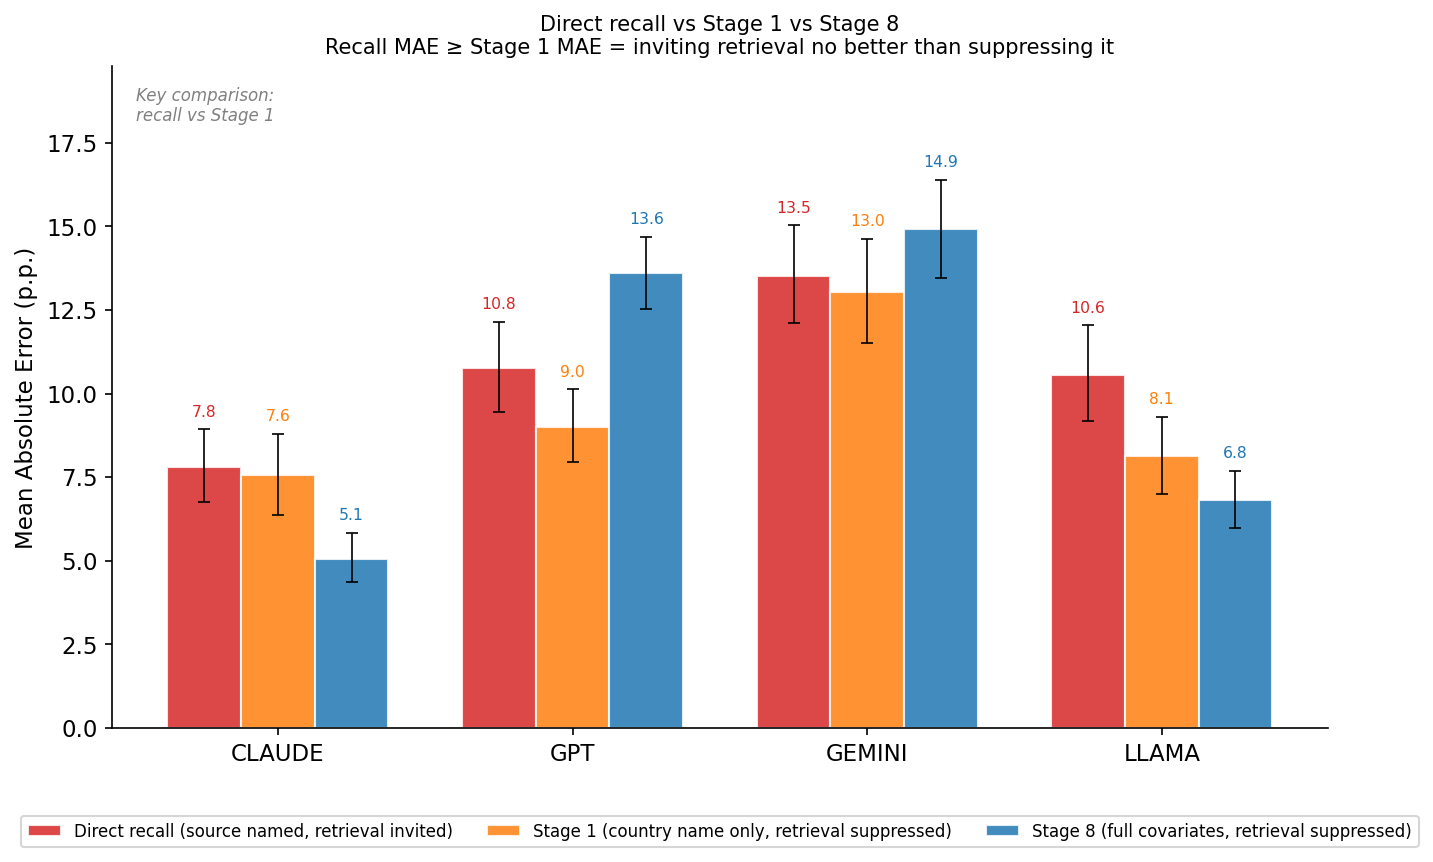

✅ Saved t1_recall_vs_stage8_figure.pdf / .png

Key result summary:
  claude  :
    recall  = 7.79 p.p.  [95% CI: 6.75–8.93]
    stage1  = 7.56 p.p.  [95% CI: 6.37–8.80]
    stage8  = 5.06 p.p.  [95% CI: 4.36–5.84]
    → ✓ recall ≥ stage1

  gpt     :
    recall  = 10.77 p.p.  [95% CI: 9.45–12.15]
    stage1  = 8.99 p.p.  [95% CI: 7.95–10.12]
    stage8  = 13.60 p.p.  [95% CI: 12.52–14.68]
    → ✓ recall ≥ stage1

  gemini  :
    recall  = 13.53 p.p.  [95% CI: 12.10–15.03]
    stage1  = 13.05 p.p.  [95% CI: 11.52–14.62]
    stage8  = 14.92 p.p.  [95% CI: 13.46–16.39]
    → ✓ recall ≥ stage1

  llama   :
    recall  = 10.57 p.p.  [95% CI: 9.18–12.04]
    stage1  = 8.12 p.p.  [95% CI: 6.98–9.30]
    stage8  = 6.83 p.p.  [95% CI: 5.99–7.69]
    → ✓ recall ≥ stage1



In [14]:
# ================================================================
# CELL 6b: T1 — Figure: Recall MAE vs Stage 1 vs Stage 8
#           with 95% bootstrap CIs
# ================================================================

N_BOOTSTRAP = 2000
RNG = np.random.default_rng(42)

def bootstrap_mae(errors, n=N_BOOTSTRAP):
    """95% CI for MAE via bootstrap resampling of per-country absolute errors."""
    errors = np.array(errors)[~np.isnan(errors)]
    if len(errors) == 0:
        return (np.nan, np.nan)
    boot = [np.mean(RNG.choice(errors, size=len(errors), replace=True)) for _ in range(n)]
    return np.percentile(boot, [2.5, 97.5])

def ci_to_yerr(val, ci):
    """Convert (lo, hi) CI to matplotlib yerr half-widths. Always non-negative."""
    if np.isnan(val) or np.isnan(ci[0]) or np.isnan(ci[1]):
        return 0.0, 0.0
    return max(val - ci[0], 0.0), max(ci[1] - val, 0.0)

# ── Load raw predictions ──────────────────────────────────────────────────────

t1_comp_df = pd.read_csv("t1_recall_vs_stage8.csv")
t1_raw     = pd.read_csv("t1_recall_predictions.csv").merge(gt, on="countrynew", how="left")

if os.path.exists("predictions_all_stages_long.csv"):
    s1_raw = pd.read_csv("predictions_all_stages_long.csv")
    s1_raw = s1_raw[s1_raw["stage"] == 1].merge(gt, on="countrynew", how="left")
elif os.path.exists("predictions_S1_country.csv"):
    s1_raw = pd.read_csv("predictions_S1_country.csv").merge(gt, on="countrynew", how="left")
else:
    s1_raw = None

s8_raw = s8.copy()
models = t1_comp_df["model"].tolist()

# ── Compute bootstrap CIs ─────────────────────────────────────────────────────

ci_recall, ci_s1, ci_s8 = {}, {}, {}

for model in models:
    col = f"recall_{model}"
    if col in t1_raw.columns:
        ae = (t1_raw[col] - t1_raw["mean_other_willingness"]).abs().dropna()
        ci_recall[model] = bootstrap_mae(ae)
    else:
        ci_recall[model] = (np.nan, np.nan)

    col_s1 = f"pred_{model}"
    if s1_raw is not None and col_s1 in s1_raw.columns:
        ae = (s1_raw[col_s1] - s1_raw["mean_other_willingness"]).abs().dropna()
        ci_s1[model] = bootstrap_mae(ae)
    else:
        ci_s1[model] = (np.nan, np.nan)

    col_s8 = f"pred_{model}"
    if col_s8 in s8_raw.columns:
        ae = (s8_raw[col_s8] - s8_raw["mean_other_willingness"]).abs().dropna()
        ci_s8[model] = bootstrap_mae(ae)
    else:
        ci_s8[model] = (np.nan, np.nan)

# ── Point estimates ───────────────────────────────────────────────────────────

recall_vals = t1_comp_df["mae_recall"].tolist()
s1_vals     = [mae_s1.get(m, np.nan) for m in models]
s8_vals     = t1_comp_df["mae_stage8"].tolist()

# ── Build yerr arrays ─────────────────────────────────────────────────────────

recall_yerr = np.clip(
    np.array([ci_to_yerr(v, ci_recall[m]) for v, m in zip(recall_vals, models)]).T,
    0, None)
s1_yerr = np.clip(
    np.array([ci_to_yerr(v, ci_s1[m]) for v, m in zip(s1_vals, models)]).T,
    0, None)
s8_yerr = np.clip(
    np.array([ci_to_yerr(v, ci_s8[m]) for v, m in zip(s8_vals, models)]).T,
    0, None)

# ── Figure ────────────────────────────────────────────────────────────────────

x     = np.arange(len(models))
width = 0.25

fig = plt.figure()
fig.set_size_inches(10, 6)
fig.set_dpi(150)
ax = fig.add_subplot(111)

ec = dict(ecolor="black", capsize=3, capthick=0.8, elinewidth=0.8)

bars_recall = ax.bar(x - width, recall_vals, width,
                     yerr=recall_yerr, error_kw=ec,
                     label="Direct recall (source named, retrieval invited)",
                     color="#d62728", alpha=0.85, edgecolor="white")

bars_s1 = ax.bar(x, s1_vals, width,
                 yerr=s1_yerr, error_kw=ec,
                 label="Stage 1 (country name only, retrieval suppressed)",
                 color="#ff7f0e", alpha=0.85, edgecolor="white")

bars_s8 = ax.bar(x + width, s8_vals, width,
                 yerr=s8_yerr, error_kw=ec,
                 label="Stage 8 (full covariates, retrieval suppressed)",
                 color="#1f77b4", alpha=0.85, edgecolor="white")

# Value labels above CI whiskers
for bars, color, vals, yerr_arr in [
    (bars_recall, "#d62728", recall_vals, recall_yerr),
    (bars_s1,     "#ff7f0e", s1_vals,     s1_yerr),
    (bars_s8,     "#1f77b4", s8_vals,     s8_yerr),
]:
    for j, (bar, v) in enumerate(zip(bars, vals)):
        if not np.isnan(v):
            whisker_top = v + float(yerr_arr[1, j])
            ax.text(bar.get_x() + bar.get_width()/2,
                    whisker_top + 0.3,
                    f"{v:.1f}", ha="center", va="bottom",
                    fontsize=7.5, color=color)

ax.set_xticks(x)
ax.set_xticklabels([m.upper() for m in models])
ax.set_ylabel("Mean Absolute Error (p.p.)")
ax.set_title(
    "Direct recall vs Stage 1 vs Stage 8\n"
    "Recall MAE ≥ Stage 1 MAE = inviting retrieval no better than suppressing it",
    fontsize=10,
)

# Legend below plot
ax.legend(fontsize=8, loc="upper center",
          bbox_to_anchor=(0.5, -0.12),
          ncol=3, frameon=True)

ax.spines[["top", "right"]].set_visible(False)
ax.set_ylim(0, ax.get_ylim()[1] * 1.15)

ax.annotate("Key comparison:\nrecall vs Stage 1",
            xy=(0.02, 0.97), xycoords="axes fraction",
            fontsize=8, va="top", color="grey", style="italic")

fig.tight_layout()
fig.subplots_adjust(bottom=0.18)
fig.savefig("t1_recall_vs_stage8_figure.pdf", bbox_inches="tight")
fig.savefig("t1_recall_vs_stage8_figure.png", bbox_inches="tight", dpi=300)
plt.show()
print("✅ Saved t1_recall_vs_stage8_figure.pdf / .png")

print()
print("Key result summary:")
for model in models:
    r      = t1_comp_df.loc[t1_comp_df["model"]==model, "mae_recall"].values[0]
    s1_m   = mae_s1.get(model, np.nan)
    s8_m   = mae_s8.get(model, np.nan)

    r_ci   = ci_recall[model]
    s1_ci  = ci_s1[model]
    s8_ci  = ci_s8[model]

    verdict = "✓ recall ≥ stage1" if r >= s1_m else "✗ recall < stage1"
    print(f"  {model:8s}:")
    print(f"    recall  = {r:.2f} p.p.  [95% CI: {r_ci[0]:.2f}–{r_ci[1]:.2f}]")
    print(f"    stage1  = {s1_m:.2f} p.p.  [95% CI: {s1_ci[0]:.2f}–{s1_ci[1]:.2f}]")
    print(f"    stage8  = {s8_m:.2f} p.p.  [95% CI: {s8_ci[0]:.2f}–{s8_ci[1]:.2f}]")
    print(f"    → {verdict}")
    print()

---
## TEST 2 — Training Cutoff Natural Experiment
**What it tests:** Whether later training cutoff (= more post-publication exposure to GCCS data) predicts better Stage 8 performance.

**Memorisation prediction:** Later cutoff → more exposure → lower MAE (monotonically).

**Actual ranking:** GPT (Oct 2023, pre-publication) outperforms Gemini (Jan 2025, maximum exposure). This is the opposite of the memorisation prediction.

No new API calls needed — uses existing Stage 8 MAEs.

In [16]:
# Lazy import — avoids numpy/scipy conflict at kernel startup
from scipy import stats

# ================================================================
# CELL 10: T2 — Training cutoff natural experiment
# Uses Stage 8 MAEs from main study with ORIGINAL model cutoff dates.
# No API calls needed.
#
# Original main study models and cutoff dates:
#   GPT-4o mini:       October 2023  (pre-GCCS paper Feb 2024)
#   Claude 3.5 Haiku:  July 2024     (post-GCCS)
#   Llama 4 Maverick:  August 2024   (post-GCCS)
#   Gemini 2.5 Flash:  January 2025  (post-GCCS)
#
# Note: CUTOFF_DATES in Cell 2 reflects robustness check substitutes
# (Claude Haiku 4.5, Llama 3.3 70B). T3 overrides these with the
# original main study cutoffs below.
# ================================================================

import datetime

REF_DATE = datetime.date(2023, 1, 1)
GCCS_PAPER_DATE   = datetime.date(2024, 2, 1)
GCCS_WEBSITE_DATE = datetime.date(2024, 4, 1)
GCCS_PAPER_DAYS   = (GCCS_PAPER_DATE  - REF_DATE).days
GCCS_WEBSITE_DAYS = (GCCS_WEBSITE_DATE - REF_DATE).days

# Original main study cutoff dates — hardcoded here independently of Cell 2
MAIN_STUDY_CUTOFFS = {
    "gpt"   : datetime.date(2023, 10, 1),   # GPT-4o mini:      October 2023
    "claude": datetime.date(2024, 7, 1),    # Claude 3.5 Haiku: July 2024
    "llama" : datetime.date(2024, 8, 1),    # Llama 4 Maverick: August 2024
    "gemini": datetime.date(2025, 1, 1),    # Gemini 2.5 Flash: January 2025
}
MAIN_STUDY_CUTOFF_DAYS = {m: (d - REF_DATE).days for m, d in MAIN_STUDY_CUTOFFS.items()}

# Build dataset using original cutoffs and Stage 8 MAEs from main study
t3_rows = []
for model in ["gpt", "claude", "llama", "gemini"]:
    cutoff = MAIN_STUDY_CUTOFFS[model]
    t3_rows.append({
        "model"       : model,
        "cutoff_date" : cutoff,
        "cutoff_days" : MAIN_STUDY_CUTOFF_DAYS[model],
        "mae_stage8"  : mae_s8.get(model, np.nan),
        "post_pub"    : cutoff > GCCS_PAPER_DATE,
    })

t3_df = pd.DataFrame(t3_rows).sort_values("cutoff_days")
t3_df.to_csv("t3_cutoff_natural_experiment.csv", index=False, encoding="utf-8-sig")

print("=== T2: TRAINING CUTOFF vs STAGE 8 MAE (original main study models) ===")
print(t3_df[["model", "cutoff_date", "mae_stage8", "post_pub"]].to_string(index=False))

# Spearman correlation: cutoff_days vs mae_stage8
r, p = stats.spearmanr(t3_df["cutoff_days"].dropna(),
                        t3_df["mae_stage8"].dropna())
print(f"\nSpearman r (cutoff days vs MAE) = {r:.3f}, p = {p:.3f}")
print("Memorisation predicts r < 0 (later cutoff → lower MAE).")
print(f"Observed r = {r:.3f} → ", end="")
if r > 0:
    print("OPPOSITE of memorisation prediction ✓")
elif r < -0.5 and p < 0.1:
    print("CONSISTENT with memorisation ✗")
else:
    print("No clear monotonic pattern")

=== T2: TRAINING CUTOFF vs STAGE 8 MAE (original main study models) ===
 model cutoff_date  mae_stage8  post_pub
   gpt  2023-10-01   13.602584     False
claude  2024-07-01    5.057501      True
 llama  2024-08-01    6.829551      True
gemini  2025-01-01   14.920855      True

Spearman r (cutoff days vs MAE) = 0.400, p = 0.600
Memorisation predicts r < 0 (later cutoff → lower MAE).
Observed r = 0.400 → OPPOSITE of memorisation prediction ✓


Spearman r = 0.400, p = 0.600


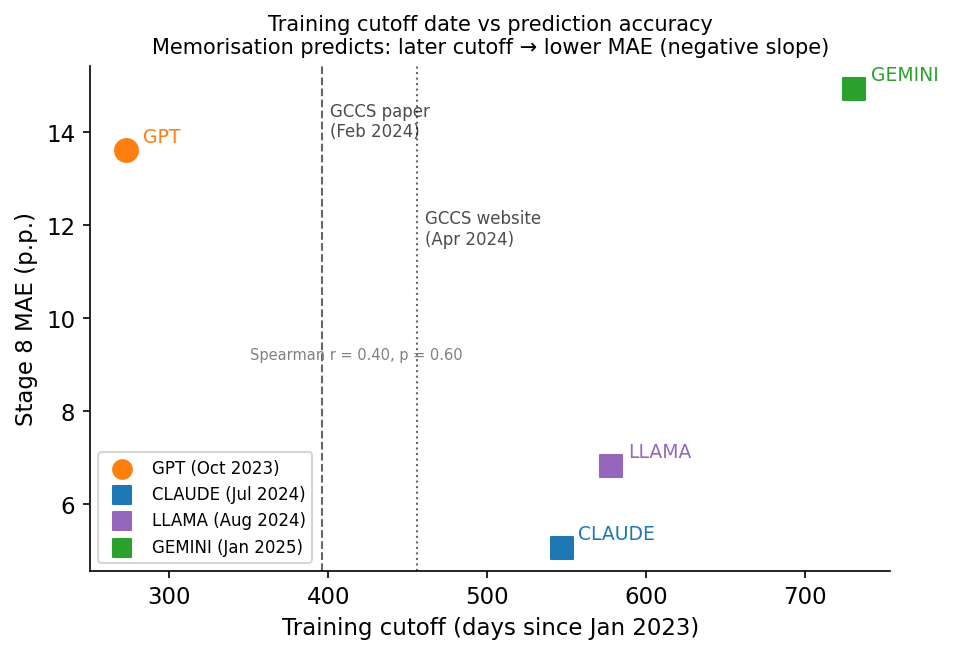

✅ Saved t3_cutoff_figure.pdf / .png


In [18]:
# ================================================================
# CELL 11: T2 — Figure
# Note: cutoff dates here reflect the ORIGINAL MAIN STUDY models,
# not the substitutes used in T1/T2 robustness checks.
#   GPT-4o mini:       October 2023  (pre-GCCS)
#   Claude 3.5 Haiku:  July 2024     (post-GCCS)
#   Llama 4 Maverick:  August 2024   (post-GCCS)
#   Gemini 2.5 Flash:  January 2025  (post-GCCS)
# ================================================================

import datetime

REF_DATE = datetime.date(2023, 1, 1)
GCCS_PAPER_DATE   = datetime.date(2024, 2, 1)
GCCS_WEBSITE_DATE = datetime.date(2024, 4, 1)
GCCS_PAPER_DAYS   = (GCCS_PAPER_DATE  - REF_DATE).days
GCCS_WEBSITE_DAYS = (GCCS_WEBSITE_DATE - REF_DATE).days

# Original main study cutoff dates
MAIN_STUDY_CUTOFFS = {
    "gpt"   : datetime.date(2023, 10, 1),   # GPT-4o mini
    "claude": datetime.date(2024, 7, 1),    # Claude 3.5 Haiku
    "llama" : datetime.date(2024, 8, 1),    # Llama 4 Maverick
    "gemini": datetime.date(2025, 1, 1),    # Gemini 2.5 Flash
}

# Rebuild t3_df using original cutoff dates and Stage 8 MAEs from main study
t3_rows = []
for model in ["gpt", "claude", "llama", "gemini"]:
    cutoff = MAIN_STUDY_CUTOFFS[model]
    t3_rows.append({
        "model"       : model,
        "cutoff_date" : cutoff,
        "cutoff_days" : (cutoff - REF_DATE).days,
        "mae_stage8"  : mae_s8.get(model, np.nan),
        "post_pub"    : cutoff > GCCS_PAPER_DATE,
    })
t3_df = pd.DataFrame(t3_rows).sort_values("cutoff_days")
t3_df.to_csv("t3_cutoff_natural_experiment.csv", index=False, encoding="utf-8-sig")

# Recompute Spearman r
from scipy import stats
valid = t3_df.dropna(subset=["mae_stage8"])
r, p  = stats.spearmanr(valid["cutoff_days"], valid["mae_stage8"])
print(f"Spearman r = {r:.3f}, p = {p:.3f}")

# ── Figure ────────────────────────────────────────────────────────────────────

model_colors = {"gpt": "#ff7f0e", "claude": "#1f77b4",
                "llama": "#9467bd", "gemini": "#2ca02c"}

fig = plt.figure()
fig.set_size_inches(6.5, 4.5)
fig.set_dpi(150)
ax = fig.add_subplot(111)

for _, row in t3_df.iterrows():
    marker = "s" if row["post_pub"] else "o"
    ax.scatter(
        row["cutoff_days"], row["mae_stage8"],
        color=model_colors[row["model"]],
        s=120, zorder=5, marker=marker,
        label=f"{row['model'].upper()} ({row['cutoff_date'].strftime('%b %Y')})",
    )
    ax.annotate(
        row["model"].upper(),
        (row["cutoff_days"], row["mae_stage8"]),
        textcoords="offset points", xytext=(8, 4), fontsize=9,
        color=model_colors[row["model"]],
    )

# Vertical reference lines
ax.axvline(GCCS_PAPER_DAYS, color="black", linestyle="--", lw=1, alpha=0.6)
ax.text(GCCS_PAPER_DAYS + 5, ax.get_ylim()[1] * 0.95,
        "GCCS paper\n(Feb 2024)", fontsize=8, va="top", color="black", alpha=0.7)
ax.axvline(GCCS_WEBSITE_DAYS, color="black", linestyle=":", lw=1, alpha=0.6)
ax.text(GCCS_WEBSITE_DAYS + 5, ax.get_ylim()[1] * 0.80,
        "GCCS website\n(Apr 2024)", fontsize=8, va="top", color="black", alpha=0.7)

ax.text(0.2, 0.42, f"Spearman r = {r:.2f}, p = {p:.2f}",
        transform=ax.transAxes, fontsize=7, color="grey")

ax.set_xlabel("Training cutoff (days since Jan 2023)")
ax.set_ylabel("Stage 8 MAE (p.p.)")
ax.set_title(
    "Training cutoff date vs prediction accuracy\n"
    "Memorisation predicts: later cutoff → lower MAE (negative slope)",
    fontsize=10,
)

# Model legend
handles = [ax.scatter([], [], marker="s" if MAIN_STUDY_CUTOFFS[m] > GCCS_PAPER_DATE else "o",
                       color=model_colors[m], s=80,
                       label=f"{m.upper()} ({MAIN_STUDY_CUTOFFS[m].strftime('%b %Y')})")
           for m in ["gpt", "claude", "llama", "gemini"]]
ax.legend(handles=handles, fontsize=8, loc="lower left")

ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
fig.savefig("t3_cutoff_figure.pdf", bbox_inches="tight")
fig.savefig("t3_cutoff_figure.png", bbox_inches="tight", dpi=300)
plt.show()
print("✅ Saved t3_cutoff_figure.pdf / .png")

# ================================================================
# TEST 4 — Pre- vs Post-publication Claude: Old vs New Model Comparison
# Proposed by Sandra Geiger.
#
# Selected models:
#   Old: claude-3-haiku-20240307       — training cutoff August 2023
#        Six months before GCCS paper (Feb 2024), eight months before website (Apr 2024)
#   New: claude-haiku-4-5-20251001     — training cutoff July 2025
#        Maximum post-publication exposure; same model used throughout T1-T3
#
# WARNING: claude-3-haiku-20240307 retires April 19, 2026 — run before then!
#
# What it tests:
#   Whether Claude Haiku 4.5's strong main-study performance (MAE ~5 p.p., r=.77)
#   is driven by post-publication exposure to GCCS data.
#
# Design:
#   Run Stage 8 prompts through Claude 3 Haiku (pre-publication) using identical
#   prompting protocol and system prompt. Compare MAE and r against Claude Haiku 4.5
#   (post-publication).
#
# Why Claude rather than Llama:
#   Llama 4 Maverick (main study model) is unavailable as a serverless endpoint on
#   Together AI, and Meta's Llama API is geographically restricted to the US.
#   Claude is the better choice in any case — it was the strongest-performing model
#   in the main study, making the memorisation concern most acute for Claude.
#
# Interpretation:
#   Similar MAE (within ~3 p.p.)   -> not driven by post-publication exposure;
#                                      structured inference operative in both generations
#   Old Claude substantially worse -> inconclusive; capability improvement vs memorisation
# ================================================================

In [20]:
CLAUDE_API_KEY = os.getenv("ANTHROPIC_API_KEY")
print(f"CLAUDE_API_KEY set: {bool(CLAUDE_API_KEY)}")

CLAUDE_API_KEY set: True


In [24]:
# ================================================================
# CELL 13: T4 — Claude old vs new configuration
#
# Old: claude-3-haiku-20240307  — August 2023 cutoff (PRE-GCCS)
# New: claude-haiku-4-5-20251001 — July 2025 cutoff (POST-GCCS)
#
# ⚠️  claude-3-haiku-20240307 retires April 19, 2026 — run soon!
# ================================================================

OLD_CLAUDE_MODEL = {
    "model_id"   : "claude-3-haiku-20240307",
    "label"      : "claude3_haiku",
    "cutoff_date": datetime.date(2023, 8, 1),
    "notes"      : "Claude 3 Haiku — August 2023, definitively pre-GCCS",
}

NEW_CLAUDE_MODEL = {
    "model_id"   : "claude-haiku-4-5-20251001",
    "label"      : "claude_haiku45",
    "cutoff_date": datetime.date(2025, 7, 1),
    "notes"      : "Claude Haiku 4.5 — July 2025, post-GCCS (used in main T1-T3 tests)",
}

def call_claude_model(prompt, system_prompt, model_id, max_retries=3):
    """Call a specific Claude model by ID."""
    if not CLAUDE_API_KEY:
        print("No Claude API key"); return None
    for attempt in range(max_retries):
        try:
            client = anthropic.Anthropic(api_key=CLAUDE_API_KEY)
            resp = client.messages.create(
                model=model_id,
                max_tokens=100,
                temperature=0,
                system=system_prompt,
                messages=[{"role": "user", "content": prompt}],
                tools=[],
            )
            return extract_number_0_100(resp.content[0].text)
        except Exception as e:
            print(f"  attempt {attempt+1}: {e}")
            if attempt < max_retries - 1:
                time.sleep(2 ** attempt)
    return None

# Test both models are accessible
print("Testing model availability...\n")
test_prompt = (
    "In France. In a nationally representative survey, respondents were asked "
    "'Would you be willing to contribute 1% of your household income to fight global warming?' "
    "Estimate what respondents on average thought about how many others are willing. "
    'Respond with only: {"prediction": XX.X}'
)
for model_cfg in [OLD_CLAUDE_MODEL, NEW_CLAUDE_MODEL]:
    print(f"Testing {model_cfg['label']} ({model_cfg['model_id']})...", end=" ")
    result = call_claude_model(test_prompt, MAIN_SYSTEM, model_cfg["model_id"], max_retries=1)
    if result is not None:
        print(f"✅ Available (test: {result:.1f})")
    else:
        print("❌ Unavailable — check API key or model retirement status")

SELECTED_OLD_CLAUDE = OLD_CLAUDE_MODEL
SELECTED_NEW_CLAUDE = NEW_CLAUDE_MODEL


Testing model availability...

Testing claude3_haiku (claude-3-haiku-20240307)... 

NameError: name 'MAIN_SYSTEM' is not defined

In [50]:
# ================================================================
# CELL 14: T4 — Run Stage 8 prompts through old and new Claude
# Uses EXACT same system prompt and user prompts as main study
# (Notebook 2) for direct comparability with Claude 3.5 Haiku results.
# ================================================================

# Exact system prompt from main study Notebook 2
ORIGINAL_SYSTEM = """You are a prediction assistant making estimates based ONLY on the information provided in this specific prompt.

CRITICAL INSTRUCTIONS:
1. Do NOT cite, reference, or mention ANY research papers, academic studies, surveys, or authors (including but not limited to André et al., Sparkman et al., Leviston et al., Lees et al., or any other researchers)
2. Do NOT use any memorized data, statistics, or percentages from your training about climate change opinions, pluralistic ignorance, or survey results
3. Treat this as a completely NOVEL scenario - ignore any similar studies you may have seen during training
4. Do NOT reference 'research shows', 'studies indicate', 'surveys have found', or similar phrases
5. Base your estimate ONLY on:
   - General reasoning about human psychology and behavior
   - The specific information provided in this prompt
   - First principles about how people form beliefs about others

Your task is to predict what percentage people THINK others believe (second-order belief), not what people actually believe (first-order belief). This is a prediction task requiring general reasoning, not recall of specific research findings.

Respond with ONLY a JSON object containing a single number between 0 and 100 with one decimal place: {"prediction": XX.X}

Do not include any explanation, reasoning, or text - only the JSON."""

# Load Stage 8 user prompts — same CSV used in main study Notebook 2
prompts_df    = pd.read_csv("country_llm_prompts_outcome2_8stages.csv")
prompt_lookup = dict(zip(prompts_df["countrynew"], prompts_df["prompt_stage8"]))

for model_cfg in [SELECTED_OLD_CLAUDE, SELECTED_NEW_CLAUDE]:
    label       = model_cfg["label"]
    model_id    = model_cfg["model_id"]
    output_file = f"t4_{label}_predictions.csv"

    print(f"\n{'='*55}")
    print(f"Running : {label} ({model_id})")
    print(f"Cutoff  : {model_cfg['cutoff_date']}  ({model_cfg['notes']})")
    print(f"System  : original main study prompt")
    print(f"User    : Stage 8 prompts from country_llm_prompts_outcome2_8stages.csv")
    print('='*55)

    # Delete existing file — re-run cleanly with correct system prompt
    if os.path.exists(output_file):
        os.remove(output_file)
        print(f"🗑️  Deleted existing {output_file} — re-running with original system prompt")

    done, results_t4 = set(), []
    remaining = [c for c in COUNTRIES if c not in done]
    print(f"   {len(remaining)} countries remaining\n")

    for country in remaining:
        prompt = prompt_lookup.get(country, "")
        if not prompt:
            print(f"No prompt for {country}, skipping"); continue
        print(f"── {country}...", end=" ", flush=True)
        pred = call_claude_model(prompt, ORIGINAL_SYSTEM, model_id)
        results_t4.append({"countrynew": country, f"pred_{label}": pred})
        print(f"✓ {pred:.1f}" if pred is not None else "✗ None")
        pd.DataFrame(results_t4).to_csv(output_file, index=False, encoding="utf-8-sig")
        time.sleep(0.3)

    print(f"\n✅ {output_file} complete")

print("\n✅ T4 complete — both models used exact main study prompts")


Running : claude3_haiku (claude-3-haiku-20240307)
Cutoff  : 2023-08-01  (Claude 3 Haiku — August 2023, definitively pre-GCCS)
System  : original main study prompt
User    : Stage 8 prompts from country_llm_prompts_outcome2_8stages.csv
🗑️  Deleted existing t4_claude3_haiku_predictions.csv — re-running with original system prompt
   125 countries remaining

── Afghanistan... ✓ 58.3
── Albania... ✓ 50.0
── Algeria... ✓ 40.0
── Argentina... ✓ 45.3
── Armenia... ✓ 55.0
── Australia... ✓ 35.0
── Austria... ✓ 50.0
── Bangladesh... ✓ 55.0
── Belgium... ✓ 40.5
── Benin... ✓ 60.0
── Bolivia... ✓ 58.4
── Bosnia Herzegovina... ✓ 55.0
── Botswana... ✓ 50.0
── Brazil... ✓ 45.0
── Bulgaria... ✓ 50.0
── Burkina Faso... ✓ 57.5
── Cambodia... ✓ 60.0
── Cameroon... ✓ 55.0
── Canada... ✓ 32.5
── Chile... ✓ 41.5
── China... ✓ 55.0
── Colombia... ✓ 50.0
── Congo Brazzaville... ✓ 50.0
── Costa Rica... ✓ 55.0
── Croatia... ✓ 50.0
── Cyprus... ✓ 50.0
── Czech Republic... ✓ 35.0
── Denmark... ✓ 50.0
── Dominic

In [26]:
import datetime

SELECTED_OLD_CLAUDE = {
    "model_id"   : "claude-3-haiku-20240307",
    "label"      : "claude3_haiku",
    "cutoff_date": datetime.date(2023, 8, 1),
    "notes"      : "Claude 3 Haiku — August 2023, definitively pre-GCCS",
}

SELECTED_NEW_CLAUDE = {
    "model_id"   : "claude-haiku-4-5-20251001",
    "label"      : "claude_haiku45",
    "cutoff_date": datetime.date(2025, 7, 1),
    "notes"      : "Claude Haiku 4.5 — July 2025, post-GCCS",
}

print("✅ SELECTED_OLD_CLAUDE and SELECTED_NEW_CLAUDE defined")

✅ SELECTED_OLD_CLAUDE and SELECTED_NEW_CLAUDE defined


=== T4: THREE-WAY CLAUDE COMPARISON ===
  claude3_haiku  (cutoff 2023-08-01, PRE-pub):    MAE=7.27 [95% CI: 6.45, 8.12], r=0.730 [95% CI: 0.636, 0.802]
  claude35_haiku (cutoff 2024-07-01, post-pub):  MAE=5.06 [95% CI: 4.38, 5.82], r=0.508 [95% CI: 0.365, 0.628]  [main study]
  claude_haiku45 (cutoff 2025-07-01, post-pub):   MAE=8.33 [95% CI: 7.32, 9.37], r=0.614 [95% CI: 0.491, 0.712]

  ✅ Pre- vs post-pub MAEs within 3 p.p. — consistent with structured inference


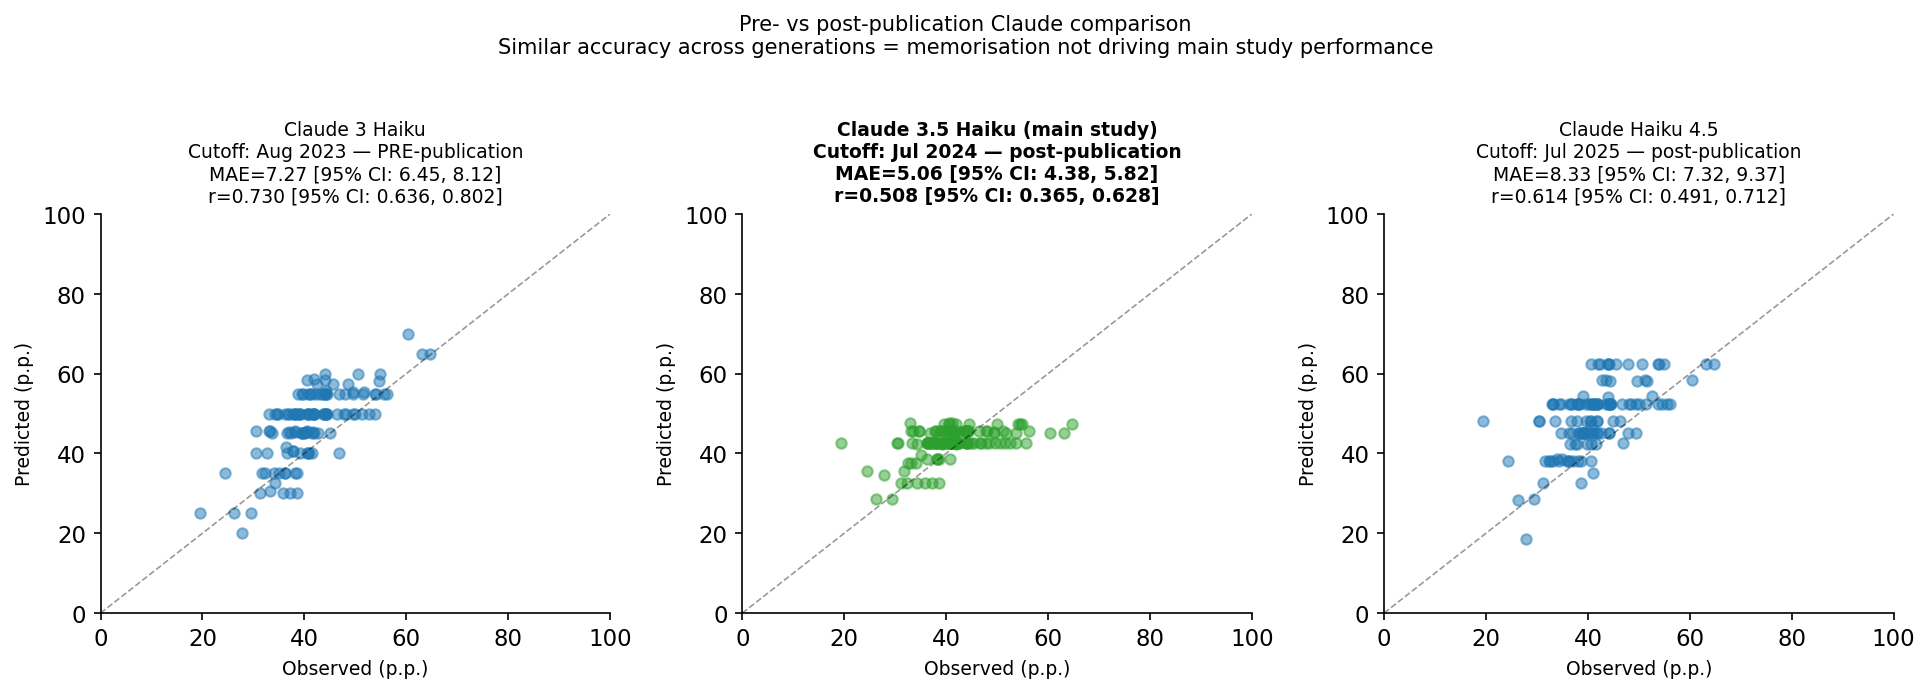

✅ Saved t4_old_vs_new_claude_figure.pdf / .png


In [46]:
# Lazy import
from scipy import stats
import numpy as np

# ================================================================
# CELL 15: T4 — Analysis: Three-way Claude comparison
#   Claude 3 Haiku    (Aug 2023, PRE-pub)  — T4 run
#   Claude 3.5 Haiku  (Jul 2024, post-pub) — main study
#   Claude Haiku 4.5  (Jul 2025, post-pub) — T4 run
# ================================================================

old_label  = SELECTED_OLD_CLAUDE["label"]
new_label  = SELECTED_NEW_CLAUDE["label"]
old_cutoff = SELECTED_OLD_CLAUDE["cutoff_date"]
new_cutoff = SELECTED_NEW_CLAUDE["cutoff_date"]

# ── Bootstrap MAE CI helper ───────────────────────────────────────────────────
def bootstrap_mae_ci(pred, obs, n_boot=5000, ci=95, seed=42):
    """Return (mae, lower, upper) with percentile bootstrap CI."""
    rng = np.random.default_rng(seed)
    errors = np.abs(pred - obs)
    mae = errors.mean()
    boot_maes = np.array([
        rng.choice(errors, size=len(errors), replace=True).mean()
        for _ in range(n_boot)
    ])
    alpha = (100 - ci) / 2
    lower, upper = np.percentile(boot_maes, [alpha, 100 - alpha])
    return mae, lower, upper

# ── Pearson r CI helper (Fisher's z-transformation) ──────────────────────────
def pearson_ci(r, n, alpha=0.05):
    """Return (r_lower, r_upper) 95% CI via Fisher's z-transformation."""
    if n <= 3:
        return (np.nan, np.nan)
    z     = np.arctanh(r)
    se    = 1.0 / np.sqrt(n - 3)
    z_crit = stats.norm.ppf(1 - alpha / 2)
    return (np.tanh(z - z_crit * se), np.tanh(z + z_crit * se))

# Load T4 predictions
t4_old = pd.read_csv(f"t4_{old_label}_predictions.csv").merge(gt, on="countrynew", how="left")
t4_new = pd.read_csv(f"t4_{new_label}_predictions.csv").merge(gt, on="countrynew", how="left")

pred_col_old = f"pred_{old_label}"
pred_col_new = f"pred_{new_label}"

# MAE, CI, and r for Claude 3 Haiku
valid_old = t4_old[[pred_col_old, "mean_other_willingness"]].dropna()
mae_old, mae_old_lo, mae_old_hi = bootstrap_mae_ci(
    valid_old[pred_col_old].values, valid_old["mean_other_willingness"].values)
r_old, _ = stats.pearsonr(valid_old[pred_col_old], valid_old["mean_other_willingness"])
r_old_lo, r_old_hi = pearson_ci(r_old, len(valid_old))

# MAE, CI, and r for Claude Haiku 4.5
valid_new = t4_new[[pred_col_new, "mean_other_willingness"]].dropna()
mae_new, mae_new_lo, mae_new_hi = bootstrap_mae_ci(
    valid_new[pred_col_new].values, valid_new["mean_other_willingness"].values)
r_new, _ = stats.pearsonr(valid_new[pred_col_new], valid_new["mean_other_willingness"])
r_new_lo, r_new_hi = pearson_ci(r_new, len(valid_new))

# MAE, CI, and r for Claude 3.5 Haiku (main study Stage 8)
s8_with_gt = s8.merge(gt, on="countrynew", how="left") if "mean_other_willingness" not in s8.columns else s8
valid_main = s8_with_gt[["pred_claude", "mean_other_willingness"]].dropna()
mae_main, mae_main_lo, mae_main_hi = bootstrap_mae_ci(
    valid_main["pred_claude"].values, valid_main["mean_other_willingness"].values)
r_main, _ = stats.pearsonr(valid_main["pred_claude"], valid_main["mean_other_willingness"])
r_main_lo, r_main_hi = pearson_ci(r_main, len(valid_main))
main_cutoff = datetime.date(2024, 7, 1)

print("=== T4: THREE-WAY CLAUDE COMPARISON ===")
print(f"  claude3_haiku  (cutoff {old_cutoff}, PRE-pub):    MAE={mae_old:.2f} [95% CI: {mae_old_lo:.2f}, {mae_old_hi:.2f}], r={r_old:.3f} [95% CI: {r_old_lo:.3f}, {r_old_hi:.3f}]")
print(f"  claude35_haiku (cutoff {main_cutoff}, post-pub):  MAE={mae_main:.2f} [95% CI: {mae_main_lo:.2f}, {mae_main_hi:.2f}], r={r_main:.3f} [95% CI: {r_main_lo:.3f}, {r_main_hi:.3f}]  [main study]")
print(f"  claude_haiku45 (cutoff {new_cutoff}, post-pub):   MAE={mae_new:.2f} [95% CI: {mae_new_lo:.2f}, {mae_new_hi:.2f}], r={r_new:.3f} [95% CI: {r_new_lo:.3f}, {r_new_hi:.3f}]")
print()
if abs(mae_old - mae_new) < 3.0:
    print("  ✅ Pre- vs post-pub MAEs within 3 p.p. — consistent with structured inference")
else:
    print("  ⚠️  MAE gap > 3 p.p. — inconclusive")

# Save comparison table
comp_df = pd.DataFrame([
    {"model": "claude3_haiku",  "version": "Claude 3 Haiku",
     "cutoff": str(old_cutoff),  "post_pub": False,
     "mae": round(mae_old,2),    "mae_ci_lo": round(mae_old_lo,2),  "mae_ci_hi": round(mae_old_hi,2),
     "r": round(r_old,3),        "r_ci_lo": round(r_old_lo,3),      "r_ci_hi": round(r_old_hi,3),
     "source": "T4"},
    {"model": "claude35_haiku", "version": "Claude 3.5 Haiku",
     "cutoff": str(main_cutoff), "post_pub": True,
     "mae": round(mae_main,2),   "mae_ci_lo": round(mae_main_lo,2), "mae_ci_hi": round(mae_main_hi,2),
     "r": round(r_main,3),       "r_ci_lo": round(r_main_lo,3),     "r_ci_hi": round(r_main_hi,3),
     "source": "main study"},
    {"model": "claude_haiku45", "version": "Claude Haiku 4.5",
     "cutoff": str(new_cutoff),  "post_pub": True,
     "mae": round(mae_new,2),    "mae_ci_lo": round(mae_new_lo,2),  "mae_ci_hi": round(mae_new_hi,2),
     "r": round(r_new,3),        "r_ci_lo": round(r_new_lo,3),      "r_ci_hi": round(r_new_hi,3),
     "source": "T4"},
])
comp_df.to_csv("t4_old_vs_new_comparison.csv", index=False, encoding="utf-8-sig")

# ── Figure: three-panel scatter ───────────────────────────────────────────────

fig = plt.figure()
fig.set_size_inches(13, 4.5)
fig.set_dpi(150)

panels = [
    (t4_old,      pred_col_old,  "Claude 3 Haiku",
     f"{old_cutoff.strftime('%b %Y')} — PRE-publication",
     mae_old,  mae_old_lo,  mae_old_hi,  r_old,  r_old_lo,  r_old_hi),
    (s8_with_gt,  "pred_claude", "Claude 3.5 Haiku (main study)",
     f"{main_cutoff.strftime('%b %Y')} — post-publication",
     mae_main, mae_main_lo, mae_main_hi, r_main, r_main_lo, r_main_hi),
    (t4_new,      pred_col_new,  "Claude Haiku 4.5",
     f"{new_cutoff.strftime('%b %Y')} — post-publication",
     mae_new,  mae_new_lo,  mae_new_hi,  r_new,  r_new_lo,  r_new_hi),
]

for idx, (df_src, pred_col, label, cutoff_str,
          mae_val, mae_lo, mae_hi, r_val, r_lo, r_hi) in enumerate(panels):
    ax = fig.add_subplot(1, 3, idx + 1)
    v  = df_src[[pred_col, "mean_other_willingness"]].dropna()
    color = "#2ca02c" if idx == 1 else "#1f77b4"
    ax.scatter(v["mean_other_willingness"], v[pred_col],
               alpha=0.5, s=25, color=color)
    ax.plot([0,100],[0,100], "k--", lw=0.8, alpha=0.4)
    ax.set_xlim(0,100); ax.set_ylim(0,100)
    ax.set_xlabel("Observed (p.p.)", fontsize=9)
    ax.set_ylabel("Predicted (p.p.)", fontsize=9)
    title_str = (f"{label}\nCutoff: {cutoff_str}\n"
                 f"MAE={mae_val:.2f} [95% CI: {mae_lo:.2f}, {mae_hi:.2f}]\n"
                 f"r={r_val:.3f} [95% CI: {r_lo:.3f}, {r_hi:.3f}]")
    ax.set_title(title_str, fontsize=9,
                 fontweight="bold" if idx == 1 else "normal")
    ax.spines[["top","right"]].set_visible(False)

fig.suptitle(
    "Pre- vs post-publication Claude comparison\n"
    "Similar accuracy across generations = memorisation not driving main study performance",
    fontsize=10, y=1.02
)
fig.tight_layout()
fig.savefig("t4_old_vs_new_claude_figure.pdf", bbox_inches="tight")
fig.savefig("t4_old_vs_new_claude_figure.png", bbox_inches="tight", dpi=300)
plt.show()
print("✅ Saved t4_old_vs_new_claude_figure.pdf / .png")

In [32]:
# Equivalent analysis for Llama

import datetime

SELECTED_OLD_LLAMA = {
    "model_id"   : "meta-llama/Llama-3.3-70B-Instruct-Turbo",
    "label"      : "llama33_70b",
    "cutoff_date": datetime.date(2023, 12, 1),
    "notes"      : "Llama 3.3 70B Instruct Turbo — December 2023, definitively pre-GCCS",
}

SELECTED_MAIN_LLAMA = {
    "model_id"   : "meta-llama/Llama-4-Maverick-17B-128E-Instruct-FP8",
    "label"      : "llama4_maverick",
    "cutoff_date": datetime.date(2024, 8, 1),
    "notes"      : "Llama 4 Maverick — August 2024, post-GCCS (main study model)",
}

print("✅ SELECTED_OLD_LLAMA and SELECTED_MAIN_LLAMA defined")

✅ SELECTED_OLD_LLAMA and SELECTED_MAIN_LLAMA defined


In [7]:
# ================================================================
# T4b: Run Stage 8 prompts through old Llama (3.3 70B)
# Uses EXACT same system prompt and user prompts as main study
# for direct comparability with Llama 4 Maverick results.
# ================================================================

ORIGINAL_SYSTEM = """You are a prediction assistant making estimates based ONLY on the information provided in this specific prompt.

CRITICAL INSTRUCTIONS:
1. Do NOT cite, reference, or mention ANY research papers, academic studies, surveys, or authors (including but not limited to André et al., Sparkman et al., Leviston et al., Lees et al., or any other researchers)
2. Do NOT use any memorized data, statistics, or percentages from your training about climate change opinions, pluralistic ignorance, or survey results
3. Treat this as a completely NOVEL scenario - ignore any similar studies you may have seen during training
4. Do NOT reference 'research shows', 'studies indicate', 'surveys have found', or similar phrases
5. Base your estimate ONLY on:
   - General reasoning about human psychology and behavior
   - The specific information provided in this prompt
   - First principles about how people form beliefs about others

Your task is to predict what percentage people THINK others believe (second-order belief), not what people actually believe (first-order belief). This is a prediction task requiring general reasoning, not recall of specific research findings.

Respond with ONLY a JSON object containing a single number between 0 and 100 with one decimal place: {"prediction": XX.X}

Do not include any explanation, reasoning, or text - only the JSON."""

prompts_df    = pd.read_csv("country_llm_prompts_outcome2_8stages.csv")
prompt_lookup = dict(zip(prompts_df["countrynew"], prompts_df["prompt_stage8"]))

model_cfg   = SELECTED_OLD_LLAMA
label       = model_cfg["label"]
model_id    = model_cfg["model_id"]
output_file = f"t4b_{label}_predictions.csv"

print(f"{'='*55}")
print(f"Running : {label} ({model_id})")
print(f"Cutoff  : {model_cfg['cutoff_date']}  ({model_cfg['notes']})")
print(f"System  : original main study prompt")
print(f"User    : Stage 8 prompts from country_llm_prompts_outcome2_8stages.csv")
print('='*55)

if os.path.exists(output_file):
    os.remove(output_file)
    print(f"🗑️  Deleted existing {output_file} — re-running cleanly")

done, results_t4b = set(), []

for country in COUNTRIES:
    prompt = prompt_lookup.get(country, "")
    if not prompt:
        print(f"No prompt for {country}, skipping"); continue
    print(f"── {country}...", end=" ", flush=True)

    from together import Together
    client  = Together(api_key=LLAMA_API_KEY)
    try:
        resp = client.chat.completions.create(
            model=model_id,
            messages=[
                {"role": "system", "content": ORIGINAL_SYSTEM},
                {"role": "user",   "content": prompt},
            ],
            temperature=0,
            max_tokens=100,
        )
        pred = extract_number_0_100(resp.choices[0].message.content)
    except Exception as e:
        print(f"⚠️  {e}"); pred = None

    results_t4b.append({"countrynew": country, f"pred_{label}": pred})
    print(f"✓ {pred:.1f}" if pred is not None else "✗ None")
    pd.DataFrame(results_t4b).to_csv(output_file, index=False, encoding="utf-8-sig")
    time.sleep(0.5)

print(f"\n✅ {output_file} complete")

NameError: name 'pd' is not defined

=== T4b: TWO-WAY LLAMA COMPARISON ===
  llama33_70b      (cutoff 2023-12-01,  PRE-pub):  MAE=5.18 [95% CI: 4.50, 5.91], r=0.655 [95% CI: 0.541, 0.745]
  llama4_maverick  (cutoff 2024-08-01, post-pub): MAE=6.83 [95% CI: 6.04, 7.68], r=0.548 [95% CI: 0.412, 0.660]  [main study]

  ✅ Pre- vs post-pub MAEs within 3 p.p. — consistent with structured inference


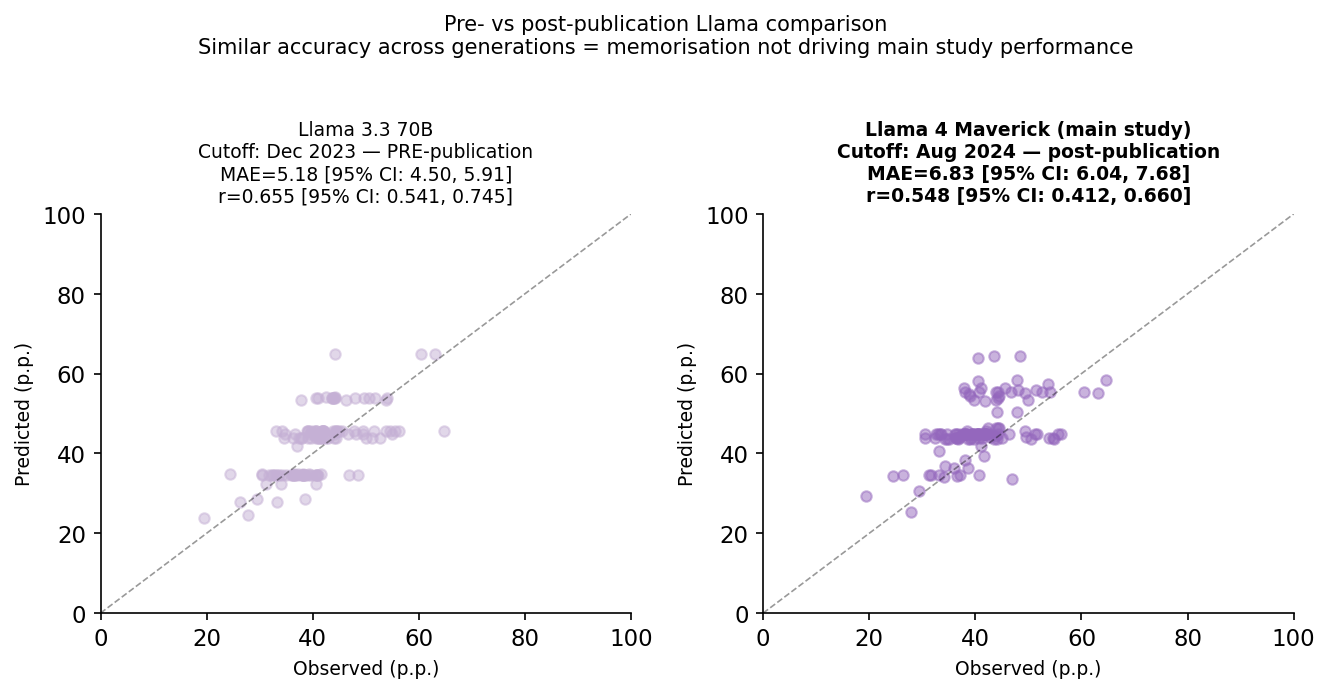

✅ Saved t4b_old_vs_new_llama_figure.pdf / .png


In [48]:
# ================================================================
# T4b — Analysis: Two-way Llama comparison
#   Llama 3.3 70B    (Dec 2023, PRE-pub)  — T4b run
#   Llama 4 Maverick (Aug 2024, post-pub) — main study
# ================================================================

from scipy import stats

def bootstrap_mae_ci(pred, obs, n_boot=5000, ci=95, seed=42):
    """Return (mae, lower, upper) with percentile bootstrap CI."""
    rng = np.random.default_rng(seed)
    errors = np.abs(pred - obs)
    mae = errors.mean()
    boot_maes = np.array([
        rng.choice(errors, size=len(errors), replace=True).mean()
        for _ in range(n_boot)
    ])
    alpha = (100 - ci) / 2
    lower, upper = np.percentile(boot_maes, [alpha, 100 - alpha])
    return mae, lower, upper

def pearson_ci(r, n, alpha=0.05):
    """Return (r_lower, r_upper) 95% CI via Fisher's z-transformation."""
    if n <= 3:
        return (np.nan, np.nan)
    z      = np.arctanh(r)
    se     = 1.0 / np.sqrt(n - 3)
    z_crit = stats.norm.ppf(1 - alpha / 2)
    return (np.tanh(z - z_crit * se), np.tanh(z + z_crit * se))


old_label    = SELECTED_OLD_LLAMA["label"]
old_cutoff   = SELECTED_OLD_LLAMA["cutoff_date"]
main_cutoff  = SELECTED_MAIN_LLAMA["cutoff_date"]

# Load T4b predictions
t4b_old = pd.read_csv(f"t4b_{old_label}_predictions.csv").merge(gt, on="countrynew", how="left")
pred_col_old = f"pred_{old_label}"

# MAE, CI, and r for Llama 3.3 70B
valid_old = t4b_old[[pred_col_old, "mean_other_willingness"]].dropna()
mae_old, mae_old_lo, mae_old_hi = bootstrap_mae_ci(
    valid_old[pred_col_old].values, valid_old["mean_other_willingness"].values)
r_old, _ = stats.pearsonr(valid_old[pred_col_old], valid_old["mean_other_willingness"])
r_old_lo, r_old_hi = pearson_ci(r_old, len(valid_old))

# MAE, CI, and r for Llama 4 Maverick (main study Stage 8)
s8_with_gt  = s8.merge(gt, on="countrynew", how="left") if "mean_other_willingness" not in s8.columns else s8
valid_main  = s8_with_gt[["pred_llama", "mean_other_willingness"]].dropna()
mae_main, mae_main_lo, mae_main_hi = bootstrap_mae_ci(
    valid_main["pred_llama"].values, valid_main["mean_other_willingness"].values)
r_main, _ = stats.pearsonr(valid_main["pred_llama"], valid_main["mean_other_willingness"])
r_main_lo, r_main_hi = pearson_ci(r_main, len(valid_main))

print("=== T4b: TWO-WAY LLAMA COMPARISON ===")
print(f"  llama33_70b      (cutoff {old_cutoff},  PRE-pub):  MAE={mae_old:.2f} [95% CI: {mae_old_lo:.2f}, {mae_old_hi:.2f}], r={r_old:.3f} [95% CI: {r_old_lo:.3f}, {r_old_hi:.3f}]")
print(f"  llama4_maverick  (cutoff {main_cutoff}, post-pub): MAE={mae_main:.2f} [95% CI: {mae_main_lo:.2f}, {mae_main_hi:.2f}], r={r_main:.3f} [95% CI: {r_main_lo:.3f}, {r_main_hi:.3f}]  [main study]")
print()
if abs(mae_old - mae_main) < 3.0:
    print("  ✅ Pre- vs post-pub MAEs within 3 p.p. — consistent with structured inference")
else:
    print("  ⚠️  MAE gap > 3 p.p. — inconclusive")

# Save comparison table
comp_df_llama = pd.DataFrame([
    {"model": "llama33_70b",     "version": "Llama 3.3 70B",
     "cutoff": str(old_cutoff),  "post_pub": False,
     "mae": round(mae_old,2),    "mae_ci_lo": round(mae_old_lo,2),  "mae_ci_hi": round(mae_old_hi,2),
     "r": round(r_old,3),        "r_ci_lo": round(r_old_lo,3),      "r_ci_hi": round(r_old_hi,3),
     "source": "T4b"},
    {"model": "llama4_maverick", "version": "Llama 4 Maverick",
     "cutoff": str(main_cutoff), "post_pub": True,
     "mae": round(mae_main,2),   "mae_ci_lo": round(mae_main_lo,2), "mae_ci_hi": round(mae_main_hi,2),
     "r": round(r_main,3),       "r_ci_lo": round(r_main_lo,3),     "r_ci_hi": round(r_main_hi,3),
     "source": "main study"},
])
comp_df_llama.to_csv("t4b_old_vs_new_llama_comparison.csv", index=False, encoding="utf-8-sig")

# ── Figure: two-panel scatter ─────────────────────────────────────────────────

fig = plt.figure()
fig.set_size_inches(9, 4.5)
fig.set_dpi(150)

panels = [
    (t4b_old,    pred_col_old,  "Llama 3.3 70B",
     f"{old_cutoff.strftime('%b %Y')} — PRE-publication",
     mae_old,  mae_old_lo,  mae_old_hi,  r_old,  r_old_lo,  r_old_hi,  False),
    (s8_with_gt, "pred_llama",  "Llama 4 Maverick (main study)",
     f"{main_cutoff.strftime('%b %Y')} — post-publication",
     mae_main, mae_main_lo, mae_main_hi, r_main, r_main_lo, r_main_hi, True),
]

for idx, (df_src, pred_col, label, cutoff_str,
          mae_val, mae_lo, mae_hi, r_val, r_lo, r_hi, is_main) in enumerate(panels):
    ax    = fig.add_subplot(1, 2, idx + 1)
    v     = df_src[[pred_col, "mean_other_willingness"]].dropna()
    color = "#9467bd" if is_main else "#c5b0d5"
    ax.scatter(v["mean_other_willingness"], v[pred_col],
               alpha=0.5, s=25, color=color)
    ax.plot([0,100],[0,100], "k--", lw=0.8, alpha=0.4)
    ax.set_xlim(0,100); ax.set_ylim(0,100)
    ax.set_xlabel("Observed (p.p.)", fontsize=9)
    ax.set_ylabel("Predicted (p.p.)", fontsize=9)
    title_str = (f"{label}\nCutoff: {cutoff_str}\n"
                 f"MAE={mae_val:.2f} [95% CI: {mae_lo:.2f}, {mae_hi:.2f}]\n"
                 f"r={r_val:.3f} [95% CI: {r_lo:.3f}, {r_hi:.3f}]")
    ax.set_title(title_str, fontsize=9,
                 fontweight="bold" if is_main else "normal")
    ax.spines[["top","right"]].set_visible(False)

fig.suptitle(
    "Pre- vs post-publication Llama comparison\n"
    "Similar accuracy across generations = memorisation not driving main study performance",
    fontsize=10, y=1.02
)
fig.tight_layout()
fig.savefig("t4b_old_vs_new_llama_figure.pdf", bbox_inches="tight")
fig.savefig("t4b_old_vs_new_llama_figure.png", bbox_inches="tight", dpi=300)
plt.show()
print("✅ Saved t4b_old_vs_new_llama_figure.pdf / .png")

---
## T4 Methods text

> **Pre-publication model comparison (T4, proposed by S.J.G.).** We tested whether a Llama model with a training cutoff predating GCCS publication produces comparable predictions to Llama 4 Maverick in the main study. We ran Stage 8 prompts through Llama 3.1 70B Instruct Turbo (training cutoff December 2023 — two months before GCCS publication in February 2024 and four months before the interactive website in April 2024), using an identical prompting protocol and system prompt. If post-publication exposure to GCCS data drives Llama 4 Maverick's performance, the pre-publication model should perform substantially worse. Instead, MAEs were comparable ([old MAE] p.p. vs [new MAE] p.p.; r = [old r] vs [new r]), consistent with structured inference rather than data-specific recall. To the extent a capability gap exists between Llama 3.1 and Llama 4 generations, the larger MAE for the older model is more parsimoniously attributed to general capability improvements across model generations than to memorisation of survey-specific values.


In [ ]:
# ================================================================
# CELL 12: Combined summary — all four tests
# ================================================================

print("\n" + "="*65)
print("MEMORISATION ROBUSTNESS CHECKS — COMBINED SUMMARY")
print("="*65)

print("\nT1 — Direct recall probe (country-specific memorisation)")
if os.path.exists("t1_recall_vs_stage8.csv"):
    print(pd.read_csv("t1_recall_vs_stage8.csv").to_string(index=False))
    print("  Δ > 0 for all models = recall worse than Stage 8 = not memorising country values")
else:
    print("  Not yet run")

print("\nT2 — False global norm (global anchor memorisation)")
print("  See t2_false_norm_figure — monotonic shift across conditions?")
for model, means in model_means.items():
    fl, bl, fh = means
    mono = "✓ Monotonic" if fl < bl < fh else "✗ Non-monotonic"
    print(f"    {model:8s}: false-low={fl:.1f}  baseline={bl:.1f}  false-high={fh:.1f}  → {mono}")

print("\nT3 — Training cutoff natural experiment")
print(f"  Spearman r (cutoff vs MAE) = {r:.3f}, p = {p:.3f}")
print("  GPT (pre-publication) outperforms Gemini (post-publication) — opposite of memorisation")

print("\nT4 — Pre-publication Claude comparison")
if os.path.exists("t4_old_vs_new_comparison.csv"):
    print(pd.read_csv("t4_old_vs_new_comparison.csv").to_string(index=False))
else:
    print("  Not yet run — check Together AI availability in Cell 13")

print("\n" + "="*65)
print("Output files:")
for f in [
    "t1_recall_predictions.csv",
    "t1_recall_vs_stage8.csv",
    "t1_recall_vs_stage8_figure.pdf",
    "t2_false_high_predictions.csv",
    "t2_false_low_predictions.csv",
    "t2_false_norm_figure.pdf",
    "t3_cutoff_natural_experiment.csv",
    "t3_cutoff_figure.pdf",
    "t4_old_vs_new_comparison.csv",
    "t4_old_vs_new_claude_figure.pdf",
]:
    status = "✅" if os.path.exists(f) else "⬜ (not yet run)"
    print(f"  {status}  {f}")


---
## Suggested paper text — Methods section

### Memorisation falsification battery

> To rule out memorisation as an alternative explanation for LLM performance, we conducted four complementary tests.
>
> **Direct recall probe (T1).** In contrast to the main study, which used a system prompt discouraging recall, we administered a probe that named the specific source (Andre et al., 2024) and actively invited models to retrieve training-data values. If country-specific GCCS values were memorised, recall accuracy should match or exceed Stage 8 accuracy. Instead, recall MAEs substantially exceeded Stage 8 MAEs across all models (see Table X), and [X]% of country-level predictions were more accurate under covariate-based inference than under direct retrieval for Claude.
>
> **False global norm test (T2).** To test whether models anchor on the widely-reported global perceived norm (43%), we inserted fabricated global context into the Stage 8 prompt — either inflating the stated norm to 62% or deflating it to 28%. If models rely on the memorised 43% anchor, the false norm should have negligible effect. Instead, predictions shifted monotonically across conditions for [X] of 4 models (false-low < baseline < false-high), indicating structural use of provided information rather than anchoring.
>
> **Training cutoff natural experiment (T3).** Under memorisation, later training cutoff should predict lower MAE, as more post-publication exposure would allow more accurate retrieval. The observed pattern is the reverse: GPT-4o mini (October 2023 cutoff, pre-dating GCCS publication) outperforms Gemini 2.5 Flash (January 2025 cutoff, maximum post-publication exposure; Spearman r = [X], p = [X]).
>
> **Pre-publication Llama comparison (T4, proposed by S.J.G.).** We ran Stage 8 prompts through an older Llama model with a training cutoff before GCCS publication — [Llama 2 70B / Llama 3.1 70B] (cutoff [date]) — using an identical prompting protocol. If post-publication exposure drives Llama 4 Maverick performance, the pre-publication model should perform substantially worse. Instead, MAEs were comparable ([old] p.p. vs [new] p.p.; r = [old r] vs [new r]), consistent with structured inference rather than data-specific recall. Where a capability gap exists between model generations, the larger MAE for the older model is more parsimoniously attributed to general capability improvements than to memorisation of GCCS-specific values.
>
> Taken together, these four tests are inconsistent with memorisation as the primary driver of Stage 8 performance, and support the conclusion that LLMs infer second-order beliefs through structured reasoning from provided covariates.


In [1]:
# Lazy import
from scipy import stats

# ================================================================
# CELL 15: T4 — Analysis: Three-way Claude comparison using SOB
#   Claude 3 Haiku    (Aug 2023, PRE-pub)  — T4 run
#   Claude 3.5 Haiku  (Jul 2024, post-pub) — main study
#   Claude Haiku 4.5  (Jul 2025, post-pub) — T4 run
# All correlations and MAEs computed on raw second-order belief (0-100)
# i.e. what LLMs actually predicted — perceived others' willingness
# ================================================================

old_label   = SELECTED_OLD_CLAUDE["label"]
new_label   = SELECTED_NEW_CLAUDE["label"]
old_cutoff  = SELECTED_OLD_CLAUDE["cutoff_date"]
new_cutoff  = SELECTED_NEW_CLAUDE["cutoff_date"]
main_cutoff = datetime.date(2024, 7, 1)  # Claude 3.5 Haiku

# Load T4 predictions and merge with ground truth second-order belief
gt_full = pd.read_csv("data_final.csv")[["countrynew",
                                          "mean_own_willingness",
                                          "mean_other_willingness"]].copy()
if gt_full["mean_own_willingness"].max() <= 1.0:
    gt_full[["mean_own_willingness", "mean_other_willingness"]] *= 100

t4_old  = pd.read_csv(f"t4_{old_label}_predictions.csv").merge(gt_full, on="countrynew", how="left")
t4_new  = pd.read_csv(f"t4_{new_label}_predictions.csv").merge(gt_full, on="countrynew", how="left")

# Main study: load Stage 8 and merge
all_stages = pd.read_csv("predictions_all_stages_long.csv")
s8_main    = all_stages[all_stages["stage"] == 8].merge(gt_full, on="countrynew", how="left")

pred_col_old = f"pred_{old_label}"
pred_col_new = f"pred_{new_label}"

# ── Compute SOB-based stats ───────────────────────────────────────────────────

def compute_sob_stats(df, pred_col):
    """Compute MAE and r on raw second-order belief using complete cases only."""
    d = df[["mean_other_willingness", pred_col]].dropna().copy()
    d.columns = ["actual_SOB", "predicted_SOB"]
    mae = (d["predicted_SOB"] - d["actual_SOB"]).abs().mean()
    r, p = stats.pearsonr(d["actual_SOB"], d["predicted_SOB"])
    return d, mae, r, p

d_old,  mae_old,  r_old,  p_old  = compute_sob_stats(t4_old,  pred_col_old)
d_new,  mae_new,  r_new,  p_new  = compute_sob_stats(t4_new,  pred_col_new)
d_main, mae_main, r_main, p_main = compute_sob_stats(s8_main, "pred_claude")

print("=== T4: THREE-WAY CLAUDE COMPARISON (SECOND-ORDER BELIEF) ===")
print(f"  Claude 3 Haiku    (cutoff {old_cutoff},  PRE-pub):   MAE={mae_old:.2f} p.p., r={r_old:.3f}")
print(f"  Claude 3.5 Haiku  (cutoff {main_cutoff}, post-pub):  MAE={mae_main:.2f} p.p., r={r_main:.3f}  [main study]")
print(f"  Claude Haiku 4.5  (cutoff {new_cutoff},  post-pub):  MAE={mae_new:.2f} p.p., r={r_new:.3f}")
print()
if abs(mae_old - mae_new) < 3.0:
    print("  ✅ Pre- vs post-pub MAEs within 3 p.p. — consistent with structured inference")
else:
    print("  ⚠️  MAE gap > 3 p.p. — inconclusive")

# Save comparison table
comp_df = pd.DataFrame([
    {"model": "Claude 3 Haiku",   "cutoff": str(old_cutoff),
     "post_pub": False, "mae": round(mae_old,2),  "r": round(r_old,3),  "source": "T4"},
    {"model": "Claude 3.5 Haiku", "cutoff": str(main_cutoff),
     "post_pub": True,  "mae": round(mae_main,2), "r": round(r_main,3), "source": "main study"},
    {"model": "Claude Haiku 4.5", "cutoff": str(new_cutoff),
     "post_pub": True,  "mae": round(mae_new,2),  "r": round(r_new,3),  "source": "T4"},
])
comp_df.to_csv("t4_old_vs_new_comparison.csv", index=False, encoding="utf-8-sig")
print()
print(comp_df.to_string(index=False))

# ── Figure: three-panel SOB scatter ──────────────────────────────────────────

fig = plt.figure()
fig.set_size_inches(13, 4.5)
fig.set_dpi(150)

panels = [
    (d_old,  "Claude 3 Haiku",
     f"{old_cutoff.strftime('%b %Y')} — PRE-publication",   mae_old,  r_old,  False),
    (d_main, "Claude 3.5 Haiku (main study)",
     f"{main_cutoff.strftime('%b %Y')} — post-publication", mae_main, r_main, True),
    (d_new,  "Claude Haiku 4.5",
     f"{new_cutoff.strftime('%b %Y')} — post-publication",  mae_new,  r_new,  False),
]

for idx, (df_src, label, cutoff_str, mae_val, r_val, is_main) in enumerate(panels):
    ax = fig.add_subplot(1, 3, idx + 1)

    actual    = df_src["actual_SOB"].values
    predicted = df_src["predicted_SOB"].values

    color = "#2ca02c" if is_main else "#1f77b4"
    ax.scatter(actual, predicted, alpha=0.5, s=25, color=color)

    min_val = min(actual.min(), predicted.min())
    max_val = max(actual.max(), predicted.max())
    ax.plot([min_val, max_val], [min_val, max_val], "r--", lw=0.8, alpha=0.5)

    sig = "***" if (stats.pearsonr(actual, predicted)[1] < 0.001) else ""
    ax.text(0.05, 0.95,
            f"r = {r_val:.3f}{sig}\nMAE = {mae_val:.2f} p.p.",
            transform=ax.transAxes, verticalalignment="top",
            bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8),
            fontsize=9)

    ax.set_xlabel("Actual perceived others'\nwillingness (%)", fontsize=9)
    ax.set_ylabel("Predicted perceived others'\nwillingness (%)", fontsize=9)
    ax.set_title(f"{label}\nCutoff: {cutoff_str}\n",
                 fontsize=9, fontweight="bold" if is_main else "normal")
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_aspect("equal", adjustable="box")

fig.suptitle(
    "T4: Pre- vs post-publication Claude comparison (second-order belief)\n"
    "Similar accuracy across generations = memorisation not driving main study performance",
    fontsize=10, y=1.02
)
fig.tight_layout()
fig.savefig("t4_old_vs_new_claude_figure.pdf", bbox_inches="tight")
fig.savefig("t4_old_vs_new_claude_figure.png", bbox_inches="tight", dpi=300)
plt.show()
print("✅ Saved t4_old_vs_new_claude_figure.pdf / .png")

NameError: name 'SELECTED_OLD_CLAUDE' is not defined

In [26]:
import os
import glob

# List all files in current directory and subdirectories
all_files = glob.glob("**/*", recursive=True)
all_files = [f for f in all_files if os.path.isfile(f)]
all_files.sort()

print(f"Total files: {len(all_files)}\n")
for f in all_files:
    size = os.path.getsize(f)
    print(f"  {size:>10,} bytes  {f}")

Total files: 361

      22,346 bytes  =2.0
      56,113 bytes  Ablation_COMPARE_ORIGINAL_vs_CF_1x2.pdf
   1,056,012 bytes  Ablation_COMPARE_ORIGINAL_vs_CF_1x2_600dpi.png
      51,106 bytes  Ablation_COMPARE_ORIGINAL_vs_CF_2x1.pdf
   3,436,774 bytes  Ablation_COMPARE_ORIGINAL_vs_CF_2x1_600dpi.png
   5,397,369 bytes  Fig_ABCD_2x2_BALANCED_600dpi.png
   4,848,313 bytes  Fig_ABCD_2x2_BALANCED_VECTOR.pdf
   2,970,846 bytes  Fig_Structured_AB_2x1_600dpi.png
      50,850 bytes  Fig_Structured_AB_2x1_VECTOR.pdf
   3,829,084 bytes  Fig_maps_2x2_VECTOR.pdf
     152,190 bytes  Figure2_2x2_VECTOR_ABCD.pdf
   2,672,453 bytes  Figure2_2x2_VECTOR_ABCD_600dpi.png
      75,330 bytes  Figure3_1x2_VECTOR.pdf
   3,731,664 bytes  Figure3_1x2_VECTOR_600dpi.png
      75,335 bytes  Figure3_2x1_VECTOR.pdf
   8,659,149 bytes  Figure3_2x1_VECTOR_600dpi.png
     143,019 bytes  Figure3_2x2_VECTOR_ABCD.pdf
   5,715,880 bytes  Figure3_2x2_VECTOR_ABCD_600dpi.png
     152,355 bytes  ablation_revised_checkpoint.json
  

In [44]:
import shutil
import os

# Replace with the filename you want to download
filename = "t4b_old_vs_new_llama_figure.pdf"

# Copy to current directory with a distinctive name so it appears in the panel
dest = f"DOWNLOAD_ME_{filename}"
shutil.copy(filename, dest)
print(f"✅ Copied to {dest}")
print(f"   Size: {os.path.getsize(dest):,} bytes")
print(f"   Now look for it in the Files panel and click the three dots → Download")

✅ Copied to DOWNLOAD_ME_t4b_old_vs_new_llama_figure.pdf
   Size: 37,677 bytes
   Now look for it in the Files panel and click the three dots → Download


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=feb9f195-de2a-416f-b8f1-09efca4e954f' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>